In [1]:
!pip install tf-levenberg-marquardt

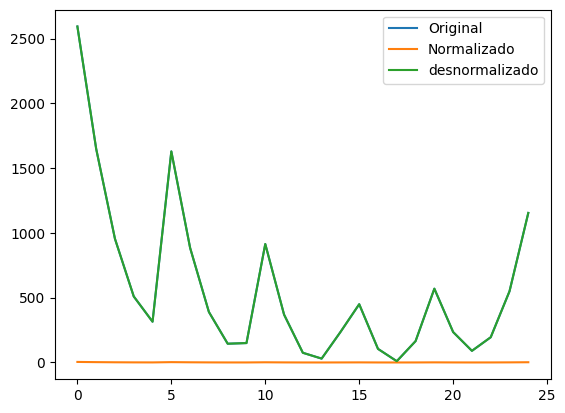

StandardScaler()

In [5]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
out_scaler = StandardScaler()
input_scaler = StandardScaler()

def  function(grid):
    x = np.linspace(-10, 10, grid)
    y = np.linspace(-10, 10, grid)
    x, y = np.meshgrid(x, y)
    z = (x + 2 * y - 7)**2 + (2 * x + y - 5)**2
    return x, y, z

def create_dataframe(grid):
   x, y, z = function(grid)
   data = {'X': x.flatten(), 'Y': y.flatten(), 'Z': z.flatten()}
   df = pd.DataFrame(data)
   return df

def show_norm(df, label="function", plot=False):
    df_norm = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    df_denorm = pd.DataFrame(scaler.inverse_transform(df_norm), columns=df_norm.columns)

    if (plot):
        df.plot(title=f"{label}: Original data")
        df_norm.plot(title=f"{label}: Normalized data")
        df_denorm.plot(title=f"{label}: Denormalized data")
    return (df_norm)

def test_out_scaler(df):
    out = df["Z"].values.reshape(-1, 1)  
    plt.plot(out, label='Original')
    out_scaler.fit(out)
    norm = out_scaler.transform(out)
    plt.plot(norm, label='Normalizado')
    denorm = out_scaler.inverse_transform(norm)
    plt.plot(denorm, label='desnormalizado')
    plt.legend()
    plt.show()

def split_df(df):
    _input = np.vstack([df['X'], df['Y']]).T
    _output = np.array(df['Z'])
    return (_input, _output)

df_25 = create_dataframe(grid=5)
df_25_norm = show_norm(df_25)
test_out_scaler(df_25)

df_1000 = create_dataframe(grid=32)
df_1000_norm = show_norm(df_1000)

_input, _output = split_df(df_25)
input_scaler.fit(_input)        

In [11]:
import tensorflow as tf
import numpy as np
from keras import regularizers
from keras import initializers
import tf_levenberg_marquardt as lm

# layers, neurons
class ShuffleArchitecture:
    def __init__(self, input_size, hidden_sizes, output_size, act_h, act_o, param_reg):
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        self.act_h = act_h
        self.act_o = act_o
        self.regularizer = regularizers.L2(param_reg)
        self.initializer = initializers.RandomUniform(minval=-0.5, maxval=0.5, seed=np.random.randint(1, 10000))

        
    def set_architecture(self):
        self.model = tf.keras.Sequential()
        self.model.add(tf.keras.layers.Dense(self.hidden_sizes[0],
                        input_shape=(self.input_size,),
                        activation=self.act_h,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,                        
                        ))  # input layer

        for size in self.hidden_sizes[1:]:  # hidden layers
            self.model.add(tf.keras.layers.Dense(size,
                            activation=self.act_h,
                            kernel_regularizer=self.regularizer,
                            kernel_initializer=self.initializer,  
                        ))

        self.model.add(tf.keras.layers.Dense(self.output_size,
                        activation=self.act_o,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,  
                        ))  # output layer

    def create_model(self, _learning_rate):

        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=_learning_rate),
            loss='mean_squared_error',
            metrics=['mse'])

        self.lm_model = lm.model.ModelWrapper(
            tf.keras.models.clone_model(self.model))
  

        self.lm_model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=_learning_rate),
            loss='mean_squared_error')
        
        return(self.lm_model)

In [13]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 
import plotly.figure_factory as ff
import plotly.offline as py
from scipy.spatial import Delaunay
import plotly.graph_objs as go
import os


class Rebuild:
    def __init__(self):
        self.df = pd.read_excel(f"better_results.xlsx")        
        self.sup_input, self.sup_output = split_df(df_1000_norm)

    def LoadModelWeights(self, model, fileName):        
        path = f"content/models/{fileName}.keras"
        model.load_weights(path)


    def LoadPrevDataset(self, fileName):
        fileName = fileName.replace("model", "dataset")
        pos = fileName.rfind("_")
        path = f"../dataset/{fileName[:pos]}.pkl" 
        with open(path, 'rb') as f:
            _data, _train, _vt, _val, _test = pickle.load(f)
        self._data, self._train, self._vt, self._val, self._test = _data, _train, _vt, _val, _test    
    
    def setArchitecture(self, _hidden_sizes, _pg, _lr):
        shuffler = ShuffleArchitecture(input_size = 2,
                                    hidden_sizes = _hidden_sizes,
                                    output_size = 1,
                                    act_h = 'tanh',
                                    act_o = 'linear',
                                    param_reg = _pg)
        shuffler.set_architecture()
        return(shuffler.create_model(_lr))            

    def getArchitecture(self, architecture):
        hidden_size = [int(x) for x in architecture.split("[")[1].split("]")[0].split(", ")]
        regularizer = float(architecture.split("regularizer=")[1].split(",")[0])
        learning_rate = float(architecture.split("learning_rate=")[1])
        return hidden_size, regularizer, learning_rate

    def PlotResults(self, original_values, predicted_values):
        titles = ['Original vs. Preditos (Completo)',
                    'Original vs. Preditos (Teste)',
                    'Original vs. Preditos (Validação)',
                    'Original vs. Preditos (Validação e Teste)']
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        for i, ax in enumerate(axes.flat):
            ax.plot(original_values[i], label='Original')
            ax.plot(predicted_values[i], label='Preditos')
            ax.set_title(titles[i])
            ax.legend()
        plt.tight_layout()
        plt.show()


    def predictResults(self, idx=-1):
        pred = self.lm_model.predict(self._data[0]).flatten()
        test_pred = self.lm_model.predict(self._test[0]).flatten()
        val_pred = self.lm_model.predict(self._val[0]).flatten()
        vt_pred = self.lm_model.predict(self._vt[0]).flatten()
        sup_pred = self.lm_model.predict(self.sup_input).flatten()

        # Calculando as metricas com a saida desnormalizada
        pred_denorm = out_scaler.inverse_transform(pred.reshape(-1, 1))
        test_pred_denorm = out_scaler.inverse_transform(test_pred.reshape(-1, 1))
        val_pred_denorm = out_scaler.inverse_transform(val_pred.reshape(-1, 1))
        vt_pred_denorm = out_scaler.inverse_transform(vt_pred.reshape(-1, 1))
        sup_pred_denorm = out_scaler.inverse_transform(sup_pred.reshape(-1, 1))

        out_denorm = out_scaler.inverse_transform(self._data[1].reshape(-1, 1))
        test_denorm = out_scaler.inverse_transform(self._test[1].reshape(-1, 1))
        val_denorm = out_scaler.inverse_transform(self._val[1].reshape(-1, 1))
        vt_denorm = out_scaler.inverse_transform(self._vt[1].reshape(-1, 1))
        sup_denorm = out_scaler.inverse_transform(self.sup_output.reshape(-1, 1))

        original_values = [out_denorm, test_denorm, val_denorm, vt_denorm, sup_denorm]
        predicted_values = [pred_denorm, test_pred_denorm, val_pred_denorm, vt_pred_denorm, sup_pred_denorm]

        if (idx != -1):
            self.RecalcMetrics(idx,
                                out_denorm, test_denorm, val_denorm, vt_denorm, sup_denorm,
                                pred_denorm, test_pred_denorm, val_pred_denorm, vt_pred_denorm, sup_pred_denorm)            
        return (original_values, predicted_values)

    def rebuildFullNet(self, model):
        for file_model, architecture in zip(self.df["model"], self.df["Architecture"]):
            if model == file_model:
                hidden_size, regularizer, learning_rate = self.getArchitecture(architecture)
                self.lm_model = self.setArchitecture(hidden_size, regularizer, learning_rate)
                self.LoadModelWeights(self.lm_model, file_model)
                self.LoadPrevDataset(file_model)
                original_values, predicted_values = self.predictResults()
                self.PlotResults(original_values, predicted_values)

    def create_dataset(self, input, output):
        input = tf.expand_dims(tf.cast(input, tf.float32), axis=-1)
        output = tf.expand_dims(tf.cast(output, tf.float32), axis=-1)
        dataset = tf.data.Dataset.from_tensor_slices((input, output))
        dataset = dataset.shuffle(len(input))
        dataset = dataset.batch(1000).cache()
        dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
        return (dataset, input, output)

    def LoadNewDataset(self):
        x = np.linspace(-10, 10, 4)
        y = np.linspace(-10, 10, 4)
        x, y = np.meshgrid(x, y)
        z = (x + 2 * y - 7)**2 + (2 * x + y - 5)**2
        x = x.flatten()
        y = y.flatten()
        z = z.flatten()
        input = np.vstack([x,y]).T
        output = np.array(z)
        dataset = pd.DataFrame(input, columns=['x', 'y'])
        dataset['z'] = output
       # dataset, input, output = self.create_dataset(input, output)
        #dataset= pd.DataFrame(input,output)
        return (input, dataset)
  
    

    def mean_std(self, df):
        df_out = df.iloc[:, 2:]
        print(df)
        mean = df_out.mean(axis=1)
        std = df_out.std(axis=1)
        df["media"] = mean
        df["desvio padrao"] = std
        display(df)
        df.to_excel('results.xlsx', index=False)

    def TestNewData(self):
        input, df = self.LoadNewDataset()
        for file_model, architecture in zip(self.df["model"], self.df["Architecture"]):
            hidden_size, regularizer, learning_rate = self.getArchitecture(architecture)
            self.lm_model = self.setArchitecture(hidden_size, regularizer, learning_rate)
            self.LoadModelWeights(self.lm_model, file_model)
            pred = self.lm_model.predict(input).flatten()
            pred_denorm = out_scaler.inverse_transform(pred.reshape(-1, 1))
            df[file_model] = pred_denorm
        self.mean_std(df)
        df.to_excel
            
                


In [ ]:
import os
print(os.getcwd())


/workspaces/Ic-Rna-2024/fuction_ensemble_3/redes-ensemble-s/Teste04


In [14]:
Rebuilder = Rebuild()

Rebuilder.TestNewData()

/workspaces/IC-RNA-2025/.conda/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.

/workspaces/IC-RNA-2025/.conda/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning:

Skipping variable loading for optimizer 'adam', because it has 14 variables whereas the saved optimizer has 0 variables. 

/workspaces/IC-RNA-2025/.conda/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning:

Skipping variable loading for optimizer 'SGD', because it has 2 variables whereas the saved optimizer has 7 variables. 



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


/workspaces/IC-RNA-2025/.conda/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.

/workspaces/IC-RNA-2025/.conda/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning:

Skipping variable loading for optimizer 'adam', because it has 14 variables whereas the saved optimizer has 0 variables. 

/workspaces/IC-RNA-2025/.conda/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning:

Skipping variable loading for optimizer 'SGD', because it has 2 variables whereas the saved optimizer has 7 variables. 

/workspaces/IC-RNA-2025/.conda/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first lay

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


/workspaces/IC-RNA-2025/.conda/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning:

Skipping variable loading for optimizer 'adam', because it has 14 variables whereas the saved optimizer has 0 variables. 

/workspaces/IC-RNA-2025/.conda/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning:

Skipping variable loading for optimizer 'SGD', because it has 2 variables whereas the saved optimizer has 7 variables. 

/workspaces/IC-RNA-2025/.conda/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.

/workspaces/IC-RNA-2025/.conda/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning:

Skipping variable loading for optimizer 'adam', because it has 14 variables whereas the saved optimizer has 0 variables. 

/workspaces/IC-RNA-202

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


/tmp/ipykernel_4113/4134661654.py:146: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/workspaces/IC-RNA-2025/.conda/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.

/workspaces/IC-RNA-2025/.conda/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning:

Skipping variable loading for optimizer 'adam', because it has 14 variables whereas the saved optimizer has 0 variables. 

/workspaces/IC-RNA-2025/.conda/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning:

Skipping variable loading for optimizer 'SGD', because it 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
            x          y            z  model_16_9_0  model_16_8_24  \
0  -10.000000 -10.000000  2594.000000   5882.501465    5877.217285   
1   -3.333333 -10.000000  1389.555556   6025.045410    6019.244629   
2    3.333333 -10.000000   629.555556   6400.657227    6392.302734   
3   10.000000 -10.000000   314.000000   2899.768066    2927.032471   
4  -10.000000  -3.333333  1362.888889   5778.962891    5771.642090   
5   -3.333333  -3.333333   514.000000   5718.065430    5713.991699   
6    3.333333  -3.333333   109.555556   1171.774658    1175.121216   
7   10.000000  -3.333333   149.555556   3240.810059    3214.960449   
8  -10.000000   3.333333   576.222222   5911.431641    5910.904297   
9   -3.333333   3.333333    82.888889   1078.462158    1076.339478   
10   3.333333   3.333333    34.000000   5019.567871    5032.095215   
11  10.000000   3.333333   429.555556   6089.819824    6095.277832   
12 -10.000000  10.000000   234.000000   4493.980469 

/workspaces/IC-RNA-2025/.conda/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning:

Skipping variable loading for optimizer 'SGD', because it has 2 variables whereas the saved optimizer has 7 variables. 

/tmp/ipykernel_4113/4134661654.py:146: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipykernel_4113/4134661654.py:133: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipykernel_4113/4134661654.py:134: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `f

,x,y,z,model_16_9_0,model_16_8_24,model_16_8_23,model_16_8_21,model_16_8_22,model_16_8_20,model_16_9_1,...,model_33_8_11,model_33_8_10,model_33_8_9,model_33_8_8,model_33_8_7,model_33_8_6,model_33_8_5,model_33_8_4,media,desvio padrao
0,-10.000000,-10.000000,2594.000000,5882.501465,5877.217285,5878.854980,5886.077637,5884.030273,5884.311523,5884.996094,...,4011.577393,4012.727051,4013.809814,4014.887695,4015.835205,4016.740234,4017.620605,4018.404785,5921.355585,1148.124137
1,-3.333333,-10.000000,1389.555556,6025.045410,6019.244629,6019.646484,6022.333984,6021.676758,6021.006836,6031.788574,...,3837.457520,3837.795654,3838.127197,3838.444336,3838.767334,3839.081299,3839.387207,3839.687012,5927.748139,1190.997608
2,3.333333,-10.000000,629.555556,6400.657227,6392.302734,6392.650879,6394.022949,6393.625000,6393.541992,6409.758789,...,3453.360596,3449.605225,3445.749756,3441.770508,3437.713379,3433.546387,3429.248779,3424.841553,5085.522699,1427.383735
3,10.000000,-10.000000,314.000000,2899.768066,2927.032471,2922.833984,2911.487549,2915.686035,2909.971924,2875.995605,...,364.284180,364.536133,364.784210,365.023285,365.268280,365.508881,365.742249,365.973389,2764.976750,1683.492017
4,-10.000000,-3.333333,1362.888889,5778.962891,5771.642090,5774.214355,5783.725098,5780.983398,5782.275879,5781.352539,...,3199.325684,3207.966553,3216.786621,3225.697510,3234.910156,3244.247803,3253.718018,3263.422607,5774.897197,1212.868924
5,-3.333333,-3.333333,514.000000,5718.065430,5713.991699,5714.642090,5717.491699,5716.801758,5716.366211,5721.548340,...,3954.923584,3956.220947,3957.504395,3958.783203,3960.045410,3961.295410,3962.541992,3963.770752,5701.752540,890.269948
6,3.333333,-3.333333,109.555556,1171.774658,1175.121216,1174.449585,1172.560059,1173.203125,1172.356079,1169.686768,...,439.946228,440.049011,440.141144,440.221802,440.297516,440.362610,440.416321,440.458649,1103.204768,197.038866
7,10.000000,-3.333333,149.555556,3240.810059,3214.960449,3214.348877,3213.992676,3213.590088,3213.522461,3283.856934,...,1673.799683,1684.125977,1694.474731,1704.822510,1715.221558,1725.575562,1735.931274,1746.323120,3099.693736,1388.651602
8,-10.000000,3.333333,576.222222,5911.431641,5910.904297,5911.909180,5915.206055,5914.696289,5914.075684,5907.521484,...,3132.249268,3131.164795,3130.067871,3128.961182,3127.845703,3126.723877,3125.592041,3124.448486,4909.126495,1824.215050
9,-3.333333,3.333333,82.888889,1078.462158,1076.339478,1076.791748,1078.257324,1077.776245,1078.285034,1079.870850,...,1264.957764,1264.715698,1264.481689,1264.270508,1264.031494,1263.811768,1263.612305,1263.400391,968.612994,218.210972
